# Binary Classification with CNNs: Kaggle Data Set
With GlobalAveragePooling layers and AdamW, early stopping on PR-AUC, decision threshold tuning, and NO transfer learning from the pneumonia MNIST data set or image resizing

## Setup

In [ ]:
# One-time setup: make the `visualization` helper importable, then fetch data +
# resolve paths. Each study's fetch logic lives in its own download_data.py.
import os
import sys

if "google.colab" in sys.modules:
    if not os.path.isdir("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    sys.path.insert(0, "ConvolutedComputerVision/src")

from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(study="chest-x-ray-images-pneumonia")

In [1]:
import datetime

import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782461446.977899 1562149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782461447.852313 1562149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
test_dir = f"{DATA_ROOT}/test"
train_dir = f"{DATA_ROOT}/train"
validation_dir = f"{DATA_ROOT}/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

In [3]:
from visualization import class_weights, show_confusion_matrix, summary_graphics

In [ ]:
class_weight = class_weights(train_ds, cache_dir=DATA_ROOT)

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

## Training

In [5]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 10

In [ ]:
# try with learning rate not as low, and unfreeze the transferred layers
transfer_model = tf.keras.models.load_model(
    os.path.join(CKPT_ROOT, "best_model_mnist.keras")
)
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.GlobalAveragePooling2D(name="5.1gap"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

# copy over the weights
# layer_names = [
#    "1.1conv",
#    "1.2conv",
#    "2.1conv",
#    "2.2conv",
# ]  # "3.1conv", "3.3conv", "4.1conv", "4.3conv", "5.2dense", "5.4dense"]
#
# for layer_name in layer_names:
#    model_1.get_layer(layer_name).set_weights(
#        transfer_model.get_layer(layer_name).get_weights()
#    )
# model_1.get_layer(layer_name).trainable = False

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [ ]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model.keras")),
)
best_model = tf.keras.models.load_model(os.path.join(CKPT_ROOT, "best_model.keras"))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step


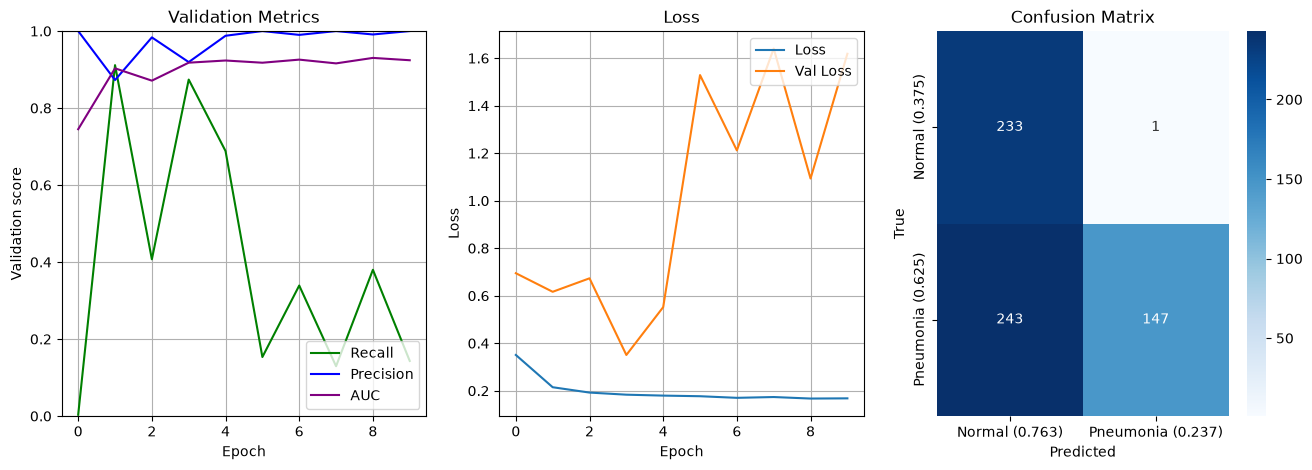

In [8]:
summary_graphics(history, best_model, test_ds)

## Tuning the decision threshold

At the default 0.5 cutoff the model has high precision but low recall (many false
negatives). Here we pick the threshold that maximizes F1 on the **validation** set
and apply it to the **test** set, recovering most of the missed pneumonia cases.

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
Tuned threshold: 0.028  (default is 0.5)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
   default 0.5: accuracy=0.609  recall=0.377  precision=0.993  false negatives=243
   tuned 0.028: accuracy=0.756  recall=0.974  precision=0.728  false negatives=10


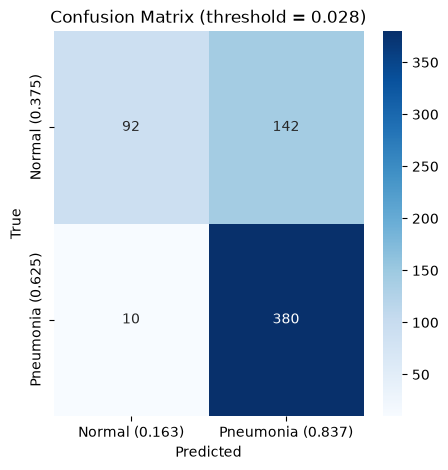

In [9]:
# Choose the decision threshold on the VALIDATION set (never on test), then apply it
# to test. The model has high precision but low recall at the default 0.5 cutoff, so a
# lower threshold trades a little precision for far fewer false negatives.
val_probs = best_model.predict(validation_ds).ravel()
y_val = np.concatenate([y for _, y in validation_ds], axis=0)

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
threshold = float(thresholds[np.argmax(f1)])
print(f"Tuned threshold: {threshold:.3f}  (default is 0.5)\n")

test_probs = best_model.predict(test_ds).ravel()
y_test = np.concatenate([y for _, y in test_ds], axis=0)

for name, thr in [("default 0.5", 0.5), (f"tuned {threshold:.3f}", threshold)]:
    pred = (test_probs >= thr).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    print(
        f"{name:>14}: accuracy={np.mean(pred == y_test):.3f}  "
        f"recall={tp / (tp + fn):.3f}  precision={tp / (tp + fp):.3f}  "
        f"false negatives={fn}"
    )

show_confusion_matrix(
    y_test,
    (test_probs >= threshold).astype("int32"),
    title=f"Confusion Matrix (threshold = {threshold:.3f})",
)

In [10]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-26 04:18:47.294207 (duration: 0:07:58.371121)
